<a href="https://colab.research.google.com/github/xegor4ikx/labs2/blob/main/%D0%9B%D0%912_%D0%A1%D0%B8%D0%BB%D1%96%D0%BD_%D0%84%D0%B3%D0%BE%D1%80_%D0%A4%D0%86%D0%A23_9_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_1_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Силін Єгор,ФІТ3-9

# Завдання 1
**Силін Єгор ФІТ3-9**

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [ ]:
import requests
import pandas as pd

In [ ]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text

tables = pd.read_html(html)
df = tables[2]
df.head()

/tmp/ipykernel_672/4023847732.py:4: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [ ]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

2.	Визначити розмір датасета.

In [ ]:
df.info

<bound method DataFrame.info of     Country/Territory IMF (2026)[1] World Bank (2025)[6]  \
0               World     126295331            118350166   
1       United States      32383920             30769700   
2          China[n 1]      20851593             19498039   
3             Germany       5452858              5050923   
4               Japan       4379253              4435163   
..                ...           ...                  ...   
217             Palau           377                  345   
218  Marshall Islands           342                  308   
219             Nauru           196                  176   
220        Montserrat          —N/a                 —N/a   
221            Tuvalu            65                   57   

    United Nations (2024)[7]  
0                  111565144  
1                   29298000  
2                   18743802  
3                    4659929  
4                    4026211  
..                       ...  
217                      310  
218                      281  
219                      187  
220                       81  
221                       56  

[222 rows x 4 columns]>

 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [ ]:
df.columns = (df.columns
              .str.replace(r'(?:\s*\[\d+\])+', '', regex=True)
              .str.replace('Country/Territory', 'Country', regex=False))

df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [ ]:
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


In [ ]:
cols = ['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']
for c in cols:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.replace(r'\[.*?\]|,|—', '', regex=True),
        errors='coerce'
    )

print(f'Types:\n{df.dtypes}')
df

Types:
Country                   object
IMF (2026)               float64
World Bank (2025)        float64
United Nations (2024)    float64
dtype: object


,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331.0,118350166.0,111565144.0
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [ ]:
df.dtypes

,0
Country,object
IMF (2026),float64
World Bank (2025),float64
United Nations (2024),float64


In [ ]:
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331.0,118350166.0,111565144.0
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [ ]:
df.isnull().sum()

,0
Country,0
IMF (2026),31
World Bank (2025),35
United Nations (2024),9


In [ ]:
df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda x: x.fillna(x.mean()), axis=1)

df.isnull().sum()

,0
Country,0
IMF (2026),8
World Bank (2025),8
United Nations (2024),8


5. Ще раз вивести датасет

In [ ]:
df.tail()

,Country,IMF (2026),World Bank (2025),United Nations (2024)
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,81.0,81.0,81.0
221,Tuvalu,65.0,57.0,56.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [ ]:
df.duplicated().sum()

np.int64(0)

7.	Вивести описову статистику датасету describe()

In [ ]:
df.describe()

,IMF (2026),World Bank (2025),United Nations (2024)
count,2.140000e+02,2.140000e+02,2.140000e+02
mean,1.181726e+06,1.106580e+06,1.043505e+06
std,9.012141e+06,8.452161e+06,7.976036e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,8.621750e+03,8.888750e+03,8.568750e+03
50%,4.424400e+04,4.041350e+04,3.736450e+04
75%,2.948788e+05,2.764912e+05,2.594152e+05
max,1.262953e+08,1.183502e+08,1.115651e+08


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [ ]:
df['IMF_WB_Diff'] = (df['IMF (2026)'] - df['World Bank (2025)']).abs()

idx = df.loc[df['Country'] != 'World', 'IMF_WB_Diff'].idxmax()
country = df.loc[idx, 'Country']
max_diff = df.loc[idx, 'IMF_WB_Diff']
print(f'{country} has the largest difference between IMF and WB: {max_diff}')

df.sort_values('IMF_WB_Diff', ascending=False).head(10)

United States has the largest difference between IMF and WB: 1614220.0


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share
0,World,126295331.0,118350166.0,111565144.0,7945165.0,5.572198e+07,0.499409,0.499772,0.499598
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07,0.128056,0.129935,0.131199
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06,0.082453,0.082337,0.083936
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06,0.021562,0.021329,0.020868
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06,0.010423,0.009628,0.009788
12,Australia,2123963.0,1798519.0,1830610.0,325444.0,8.094826e+05,0.008399,0.007595,0.008198
13,Mexico,2120855.0,1832641.0,1852723.0,288214.0,8.340105e+05,0.008386,0.007739,0.008297
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06,0.016864,0.016902,0.016506
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06,0.014220,0.014215,0.014153
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06,0.016423,0.016706,0.017698


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [ ]:
cor_IMF_WB = df['IMF (2026)'].corr(df['World Bank (2025)'])
cor_IMF_UN = df['IMF (2026)'].corr(df['United Nations (2024)'])
cor_WB_UN = df['World Bank (2025)'].corr(df['United Nations (2024)'])

print(f'Correlation between IMF and WB: {cor_IMF_WB}')
print(f'Correlation between IMF and UN: {cor_IMF_UN}')
print(f'Correlation between  WB and UN: {cor_WB_UN}')

Correlation between IMF and WB: 0.9999854383994788
Correlation between IMF and UN: 0.9999656762678482
Correlation between  WB and UN: 0.9999814895719566


In [ ]:
max_cor = max(cor_IMF_WB, cor_IMF_UN, cor_WB_UN)

if max_cor == cor_IMF_WB:
    print('IMF and WB have the highest correlation')
elif max_cor == cor_IMF_UN:
    print('IMF and UN have the highest correlation')
else:
    print('WB and UN have the highest correlation')

IMF and WB have the highest correlation


Обчислити середнє значення за стовпцями

In [ ]:
mean_IMF = df['IMF (2026)'].mean()
mean_IMF

np.float64(1181726.3364485982)

In [ ]:
mean_WB = df['World Bank (2025)'].mean()
mean_WB

np.float64(1106580.2710280374)

In [ ]:
mean_UN = df['United Nations (2024)'].mean()
mean_UN

np.float64(1043504.6682242991)

11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [ ]:
df['std'] = df.iloc[:, 1:].std(axis=1)

max_std = df['std'].max()
country = df[df['std'] == max_std]['Country'].values[0]
print(f'{country} has the highest standard deviation: {max_std}')

df.head(10)

World has the highest standard deviation: 55721978.507490404


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std
0,World,126295331.0,118350166.0,111565144.0,7945165.0,5.572198e+07
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [ ]:
max_IMF = df['IMF (2026)'].max(); min_IMF = df['IMF (2026)'].min()
max_WB = df['World Bank (2025)'].max(); min_WB = df['World Bank (2025)'].min()
max_UN = df['United Nations (2024)'].max(); min_UN = df['United Nations (2024)'].min()

print(f'Max IMF: {max_IMF}, Min IMF: {min_IMF}')
print(f'Max WB: {max_WB}, Min WB: {min_WB}')
print(f'Max UN: {max_UN}, Min UN: {min_UN}')

Max IMF: 126295331.0, Min IMF: 65.0
Max WB: 118350166.0, Min WB: 57.0
Max UN: 111565144.0, Min UN: 56.0


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

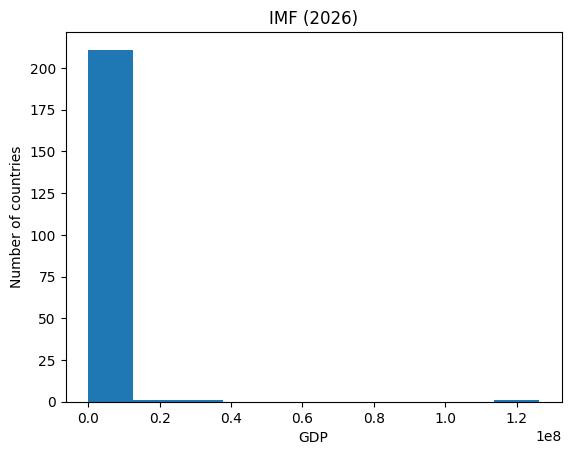

In [ ]:
import matplotlib.pyplot as plt

# Build a histogram of IMF_Forecast
plt.hist(df['IMF (2026)'], bins=10)
plt.title('IMF (2026)')
plt.xlabel('GDP')
plt.ylabel('Number of countries')
plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [ ]:
df['IMF_Share'] = df['IMF (2026)'] / df['IMF (2026)'].sum()
df['WB_Share'] = df['World Bank (2025)'] / df['World Bank (2025)'].sum()
df['UN_Share'] = df['United Nations (2024)'] / df['United Nations (2024)'].sum()

df.head(10)

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share
0,World,126295331.0,118350166.0,111565144.0,7945165.0,5.572198e+07,0.499409,0.499772,0.499598
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07,0.128056,0.129935,0.131199
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06,0.082453,0.082337,0.083936
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06,0.021562,0.021329,0.020868
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06,0.017317,0.018729,0.018030
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06,0.016864,0.016902,0.016506
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06,0.016423,0.016706,0.017698
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06,0.014220,0.014215,0.014153
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06,0.010828,0.010775,0.010662
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06,0.010504,0.010816,0.009733


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

In [ ]:
df['IMF_UN_Diff'] = abs(df['IMF_Share'] - df['UN_Share'])
df_top10 = df.nlargest(10, 'IMF_UN_Diff')
df_top10

## Висновок

У ході лабораторної роботи ми ознайомилися з обробкою та аналізом реальних даних за допомогою бібліотеки **Pandas**. Було отримано таблицю ВВП країн з Вікіпедії, визначено розмір і структуру датасету, очищено назви стовпців від посилань.